In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

### zadanie 2

In [24]:
iris = datasets.load_iris(as_frame=True)
df = iris.frame

print("Info o Iris")
print(df.info())
print("\nOpis Iris")
print(df.describe())
print("\n Head")
print(df.head(7))


Info o Iris
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Opis Iris
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000   

### zadanie 3


In [25]:
titan = pd.read_csv("../data/titan.csv")

print("\n=== Brakujące wartości przed uzupełnieniem ===")
print(titan.isnull().sum())

titan["Age"].fillna(titan["Age"].mean(), inplace=True)

titan["Cabin"].fillna("Unknown", inplace=True)
titan["Embarked"].fillna("U", inplace=True)

print("\nBrakujące wartości po uzupełnieniu")
print(titan.isnull().sum())

print("\nPrzykładowe dane Titanic")
print(titan.head())



=== Brakujące wartości przed uzupełnieniem ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Brakujące wartości po uzupełnieniu
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Przykładowe dane Titanic
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female 

C:\Users\bartek\AppData\Local\Temp\ipykernel_14712\2726903932.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titan["Age"].fillna(titan["Age"].mean(), inplace=True)
C:\Users\bartek\AppData\Local\Temp\ipykernel_14712\2726903932.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


### zadanie 4

In [26]:
titan_encoded_pd = pd.get_dummies(titan, columns=["Sex", "Embarked"], dtype=int)
print("\n=== Titanic po One-Hot Encoding (pandas) ===")
print(titan_encoded_pd.head())

cat_cols = ["Sex", "Embarked"]
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = enc.fit_transform(titan[cat_cols])

encoded_df = pd.DataFrame(encoded_array, columns=enc.get_feature_names_out(cat_cols))
titan_encoded_sklearn = pd.concat([titan.drop(columns=cat_cols), encoded_df], axis=1)

print("\n=== Titanic po One-Hot Encoding (scikit-learn) ===")
print(titan_encoded_sklearn.head())



=== Titanic po One-Hot Encoding (pandas) ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare    Cabin  Sex_female  Sex_male  Embarked_C  \
0         A/5 21171   7.2500  Unknown           0         1           0   
1          PC 17599  71.2833      C85           1         0           1   
2  STON/O2. 3101282   7.9250  Unknown           1      

### zadanie 5

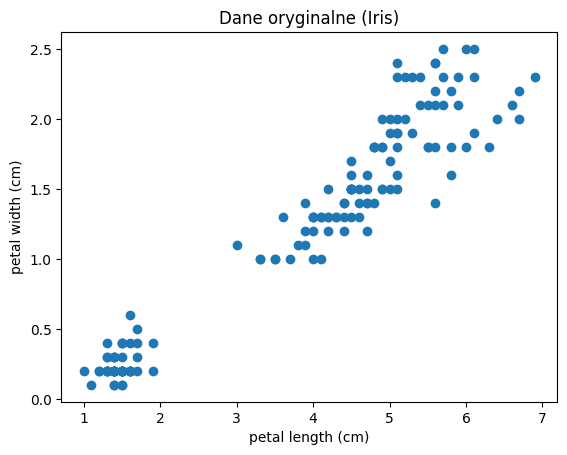

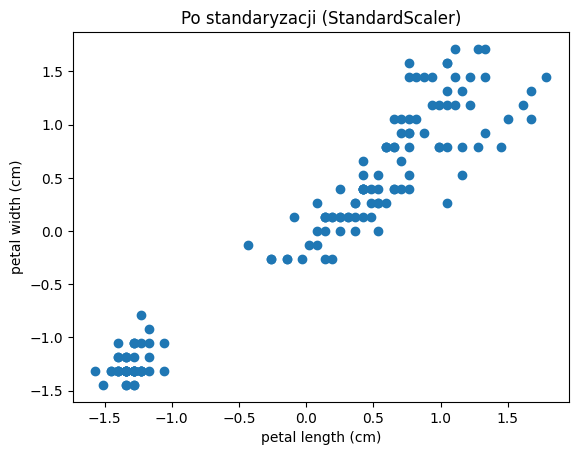

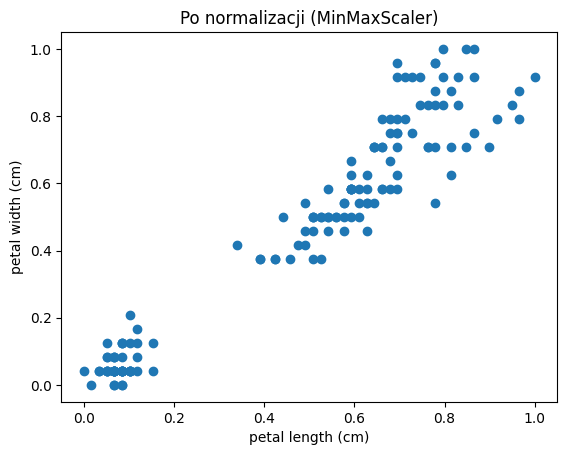

In [27]:
num_cols = ["petal length (cm)", "petal width (cm)"]

plt.scatter(df[num_cols[0]], df[num_cols[1]])
plt.title("Dane oryginalne (Iris)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

scaler_std = StandardScaler()
df_std = df.copy()
df_std[num_cols] = scaler_std.fit_transform(df[num_cols])

plt.scatter(df_std[num_cols[0]], df_std[num_cols[1]])
plt.title("Po standaryzacji (StandardScaler)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

scaler_mm = MinMaxScaler()
df_mm = df.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df[num_cols])

plt.scatter(df_mm[num_cols[0]], df_mm[num_cols[1]])
plt.title("Po normalizacji (MinMaxScaler)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

### zadanie 6

In [28]:
X_train, X_test = train_test_split(df, test_size=0.3, random_state=42)

print("\nWymiary zbiorów")
print(f"Zbiór treningowy: {X_train.shape}")
print(f"Zbiór testowy: {X_test.shape}")


Wymiary zbiorów
Zbiór treningowy: (105, 5)
Zbiór testowy: (45, 5)


### zadanie 7

In [29]:
house = pd.read_csv("../data/housing.csv")

print("\n=== Brakujące wartości przed uzupełnieniem ===")
print(house.isnull().sum())

house["total_bedrooms"].fillna(house["total_bedrooms"].mean(), inplace=True)

print("\nBrakujące wartości po uzupełnieniu")
print(house.isnull().sum())

print("\nPrzykładowe dane Housing")
print(house.head())


=== Brakujące wartości przed uzupełnieniem ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Brakujące wartości po uzupełnieniu
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Przykładowe dane Housing
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0         

C:\Users\bartek\AppData\Local\Temp\ipykernel_14712\134315840.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house["total_bedrooms"].fillna(house["total_bedrooms"].mean(), inplace=True)


In [30]:
house_encoded_pd = pd.get_dummies(house, columns=["ocean_proximity"], dtype=int)
print("\n=== Housing po One-Hot Encoding (pandas) ===")
print(house_encoded_pd.head())

cat_col = ["ocean_proximity"]
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = enc.fit_transform(house[cat_col])

encoded_df = pd.DataFrame(encoded_array, columns=enc.get_feature_names_out(cat_col))
house_encoded_sklearn = pd.concat([house.drop(columns=cat_col), encoded_df], axis=1)

print("\n=== Housing po One-Hot Encoding (scikit-learn) ===")
print(house_encoded_sklearn.head())


=== Housing po One-Hot Encoding (pandas) ===
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0                          0          

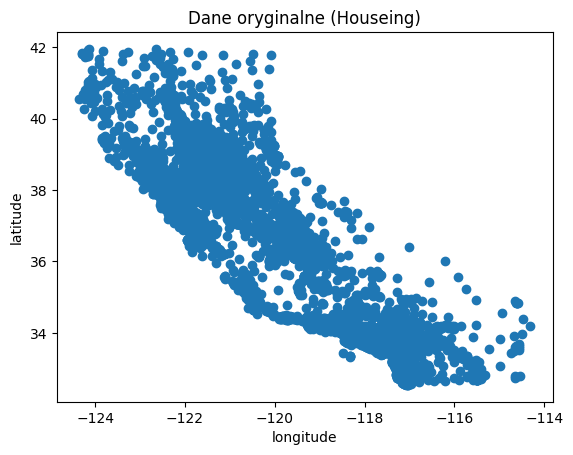

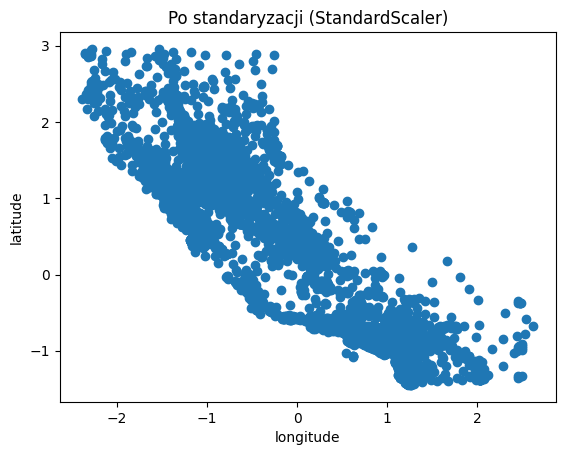

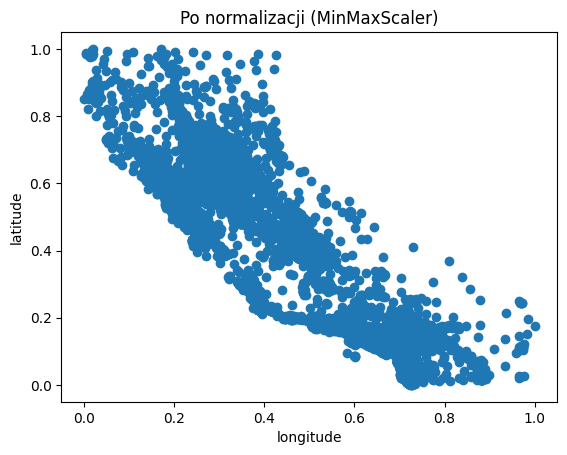

In [39]:
num_cols = ["longitude", "latitude"]

plt.scatter(house[num_cols[0]], house[num_cols[1]])
plt.title("Dane oryginalne (Houseing)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

scaler_std = StandardScaler()
house_std = house.copy()
house_std[num_cols] = scaler_std.fit_transform(house[num_cols])

plt.scatter(house_std[num_cols[0]], house_std[num_cols[1]])
plt.title("Po standaryzacji (StandardScaler)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

scaler_mm = MinMaxScaler()
house_mm = house.copy()
house_mm[num_cols] = scaler_mm.fit_transform(house[num_cols])

plt.scatter(house_mm[num_cols[0]], house_mm[num_cols[1]])
plt.title("Po normalizacji (MinMaxScaler)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()

In [ ]:
house_encoded_pd.to_csv("../data/housing_prepared.csv", index=False)